In [1]:
import sys
import os

# Adds the parent directory to the search path
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import xtrack as xt
import numpy as np
import matplotlib.pyplot  as plt
import matplotlib.patches as patches
import xpart as xp
import xobjects as xo
import math
from TuneDiagram.lib.TuneDiagram.tune_diagram import resonance_lines
from prettytable import PrettyTable
import xutil_DA_CC.xsuite_plot_functions as my_xpf
import xutil_DA_CC.xsuite_utilities as xutil
import Essentials.constants as constants
import sextupole_configs as sc
import my_functions as mf

/home/mwatson/.local/lib/python3.12/site-packages/xplt/hooks.py:31: RuntimeWarning: Failed to register formatters with pint: No module named 'pint'
  warnings.warn(f"Failed to register formatters with pint: {e}", RuntimeWarning)


In [2]:
n=2

from matplotlib.backends.backend_pdf import PdfPages
pdf = PdfPages(f"config_D{n}.pdf")

_old_savefig = plt.savefig

def _new_savefig(*args, **kwargs):
    pdf.savefig(plt.gcf())
    _old_savefig(*args, **kwargs)

plt.savefig = _new_savefig

Loading line from dict: 100%|██████████| 2981/2981 [00:00<00:00, 36252.25it/s]


Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
['QFA_1RC', 'Drarc', 'Bend1_1R1', 'Drarc', 'QDA_1R1', 'Drarc', 'Bend2_1R1', 'Drarc', 'QFA_1R1', 'Drarc', 'Bend1_1R2', 'Drarc', 'QDA_1R2', 'Drarc', 'Bend2_1R2', 'Drarc', 'QFA_1R2', 'Drarc', 'Bend1_1R3', 'Drarc', 'QDA_1R3', 'Drarc', 'Bend2_1R3', 'Drarc', 'QFA_1R3', 'Drarc', 'Bend1_1R4', 'Drarc', 'QDA_1R4', 'Drarc', 'Bend2_1R4', 'Drarc', 'QFA_1R4', 'Drarc', 'Bend1_1R5', 'Drarc', 'QDA_1R5', 'Drarc', 'Bend2_1R5', 'Drarc', 'QFA_1R5', 'Drarc', 'Bend1_1R6', 'Drarc', 'QDA_1R6', 'Drarc', 'Bend2_1R6', 'Drarc', 'QFA_1R6', 'Drarc', 'Bend1_1R7', 'Drarc', 'QDA_1R7', 'Drarc', 'Bend2_1R7', 'Drarc', 'QFA_M1R7', 'Drarc', 'Bend1_1R8', 'Drarc', 'QDA_M1R8', 'Drarc', 'Bend2_1R8', 'DrarcS', 'QFDS_1R', 'DrDSL', 'QDDS_1R', 'Drarc', 'BendDS_1R', 'DrTrans', 'QFDoub_1R', 'DrDoub', 'QDDoub_1R', 'DrTripl..164', 'RFCav_1', 'DrTripl..166', 'QDTrip_1R1', 'DrTrip

Slicing line: 100%|██████████| 172/172 [00:00<00:00, 148044.38it/s]


                                             
Optimize - start penalty: 104.9                             
Matching: model call n. 174 penalty = 3.1208e+01              
Optimize - end penalty:  31.2083                            


Could not find point within tolerance.
Matching: model call n. 175 penalty = 1.0490e+02              



RuntimeError: Could not find point within tolerance.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


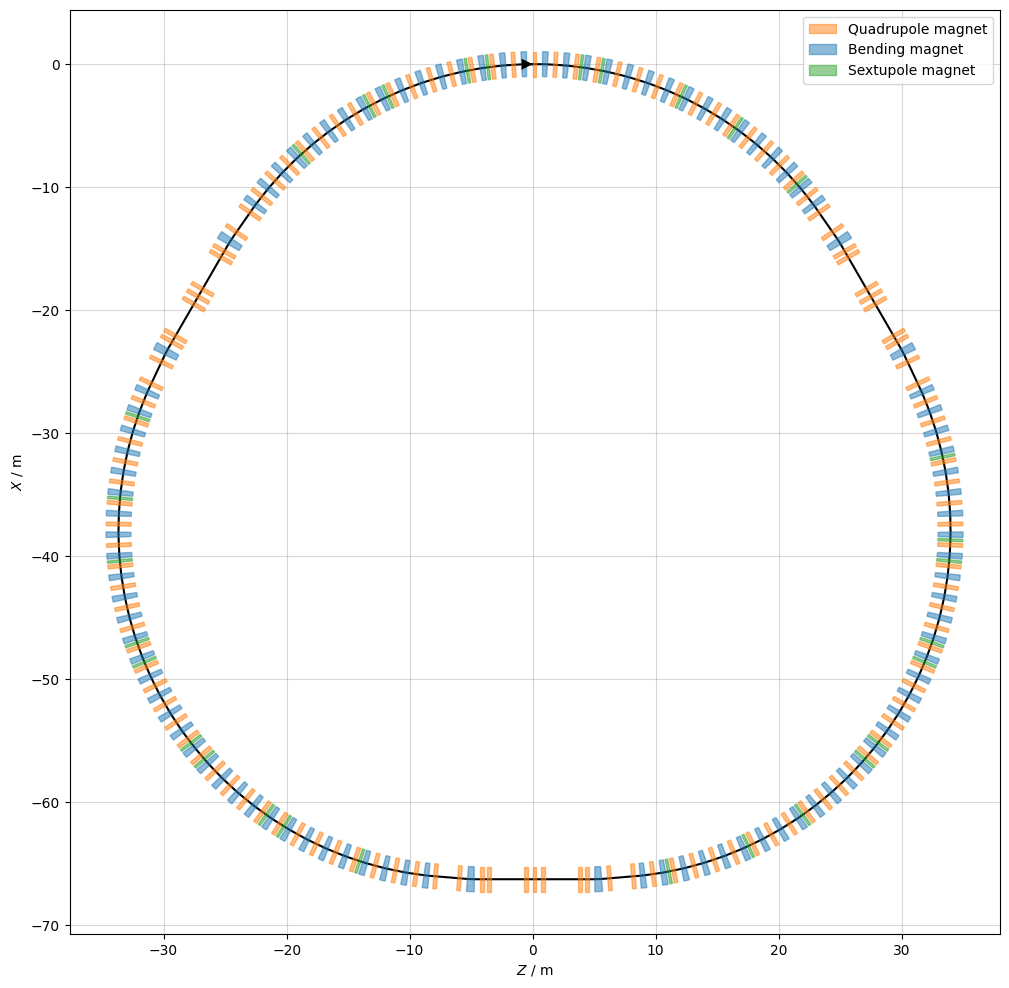

In [3]:
pdr= xt.Environment.from_json("json_files/pdr_var2.json")


#Sextupole configuration implementation
sc.config_D2(pdr)

ring=pdr.lines['ring']
period=pdr.lines['period']

In [4]:
E0 = constants.E0; VRF = constants.VRF

U0 = (0.88463e-31)*E0**4*(2.*np.pi)/(6*(2*pdr['N_cells_S']*pdr['l_bend'] + pdr['l_bendDS']) )

period_sliced = period.select()
period_sliced.cut_at_s( np.linspace(.05, period.get_length()-.05, int(period.get_length()/.05-.5)) )

ring.configure_radiation(model=None)
fRev = 1./(ring.twiss(method='4d').T_rev0)
fRF  = fRev*round(4.e8/fRev)  # at integer harmonics and close to 400 MHz

Slicing line: 100%|██████████| 174/174 [00:00<00:00, 3384.86it/s]


In [5]:
ring.configure_radiation(model='mean')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
                   spin=True, polarization=True )



Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


2nd order chrom x 367.690687579543
2nd order chrom y 408.1986437935064


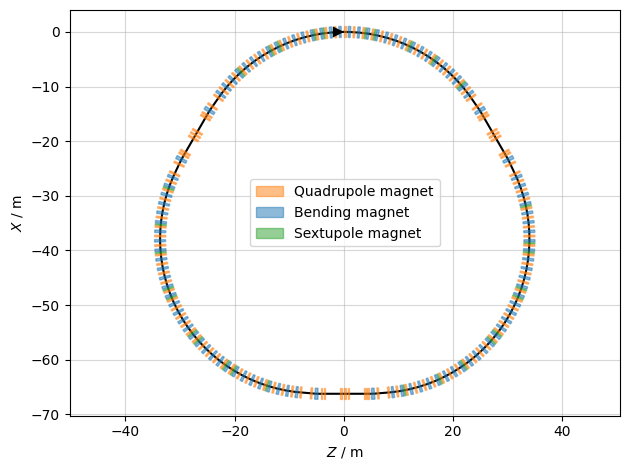

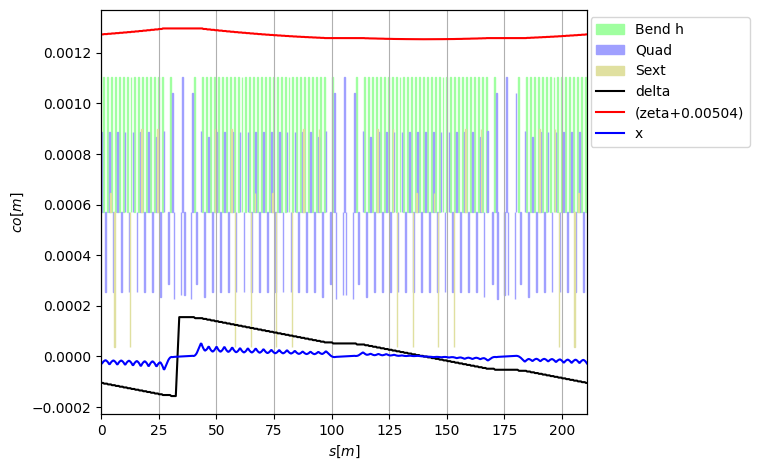

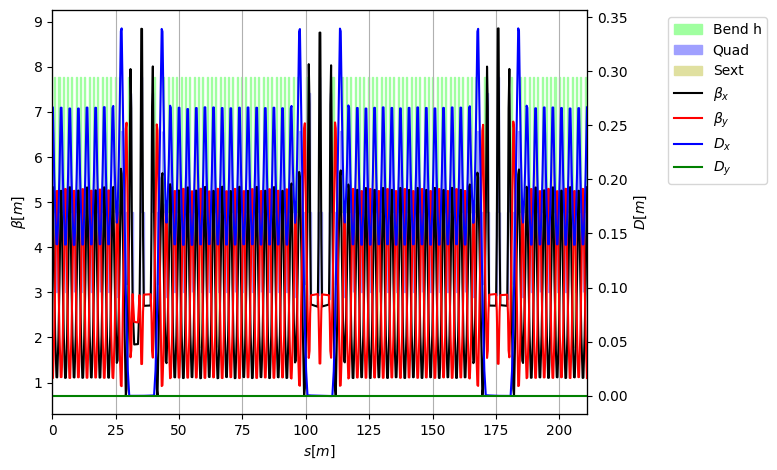

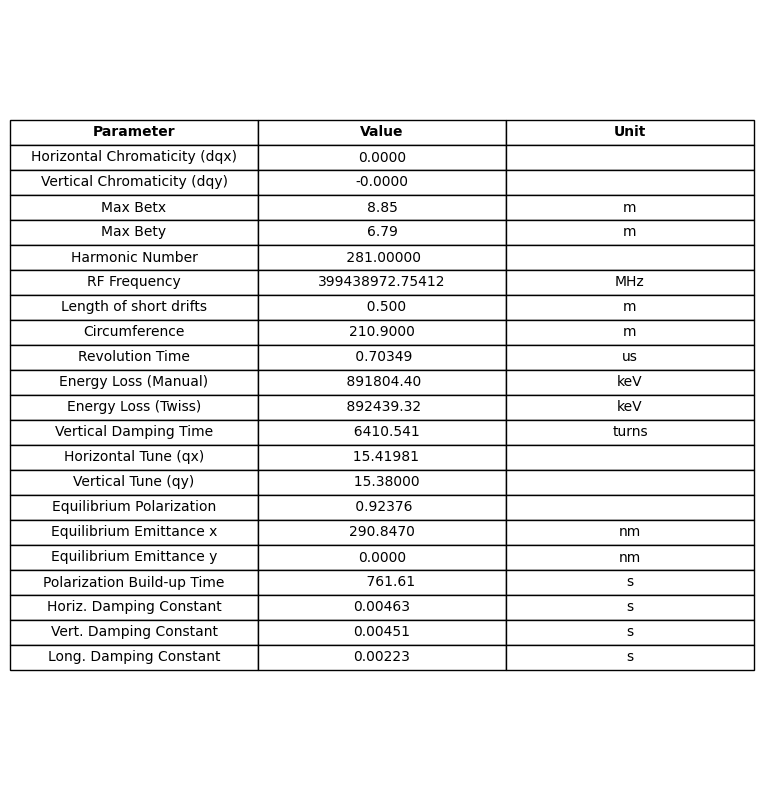

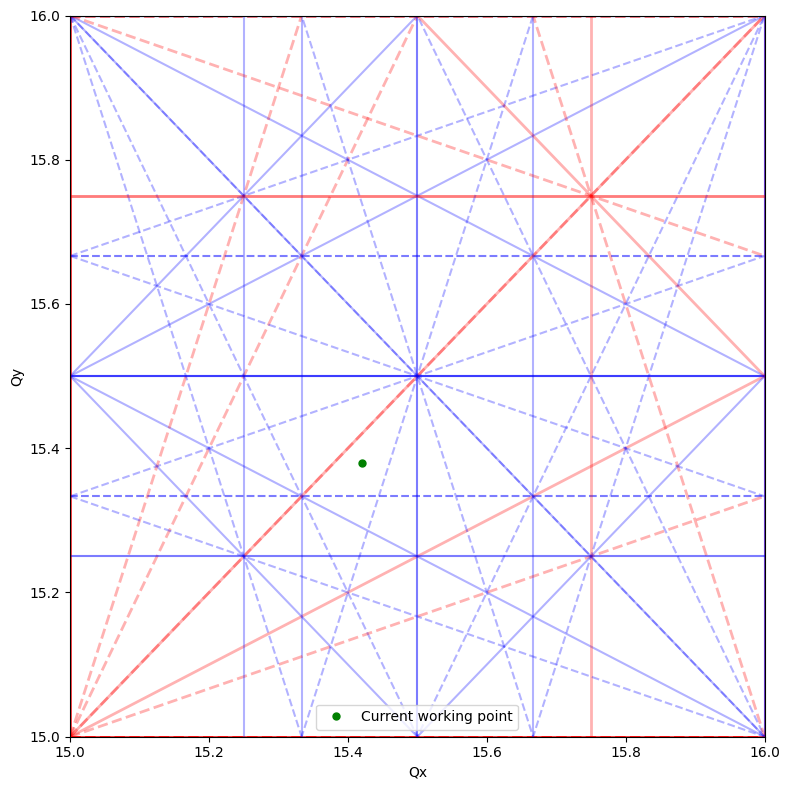

In [ ]:

ring.survey().plot()
plt.tight_layout()
plt.savefig(f'config_D{n}/ring_survey_{n}.png')

ring_tw.plot(f'delta (zeta+0.00504) x')
plt.tight_layout()
plt.savefig(f'config_D{n}/ring_delta_{n}.png')

ring_tw.plot()
plt.tight_layout()
plt.savefig(f'config_D{n}/ring_twiss_{n}.png')


def calc_damping_time_constant(m):
    num=2*E0*ring_tw.T_rev0
    den=ring_tw.partition_numbers[m]*U0
    tau=num/den
    return tau

# Initialize the table
import matplotlib.pyplot as plt

# 1. Prepare your data in a list of lists
data = [
    ["Horizontal Chromaticity (dqx)", f"{ring_tw.dqx:.4f}", ""],
    ["Vertical Chromaticity (dqy)", f"{ring_tw.dqy:.4f}", ""],
    ["Max Betx", f"{max(ring_tw.betx):.2f}", "m"],
    ["Max Bety", f"{max(ring_tw.bety):.2f}", "m"],
    ["Harmonic Number", f"{fRF/fRev:10.5f}", ""],
    ["RF Frequency", f"{fRF:8.5f}", "MHz"],
    ["Length of short drifts", f"{pdr['l_drift']:7.3f}", "m"],
    ["Circumference", f"{ring_tw.circumference:8.4f}", "m"],
    ["Revolution Time", f"{1e6*ring_tw.T_rev0:8.5f}", "us"],
    ["Energy Loss (Manual)", f"{U0:10.2f}", "keV"],
    ["Energy Loss (Twiss)", f"{ring_tw.eneloss_turn:10.2f}", "keV"],
    ["Vertical Damping Time", f"{1/ring_tw.damping_constants_turns[1]:10.3f}", "turns"],
    ["Horizontal Tune (qx)", f"{ring_tw.qx:10.5f}", ""],
    ["Vertical Tune (qy)", f"{ring_tw.qy:10.5f}", ""],
    ["Equilibrium Polarization", f"{ring_tw.spin_polarization_eq:8.5f}", ""],
    ["Equilibrium Emittance x", f"{ring_tw.eq_gemitt_x * 1e9:.4f}", "nm"],
    ["Equilibrium Emittance y", f"{ring_tw.eq_gemitt_y * 1e9:.4f}", "nm"],
    ["Polarization Build-up Time", f"{ring_tw.spin_t_pol_buildup_s:10.2f}", "s"],
    ["Horiz. Damping Constant", f"{1/ring_tw.damping_constants_s[0]:.5f}", "s"],
    ["Vert. Damping Constant", f"{1/ring_tw.damping_constants_s[1]:.5f}", "s"],
    ["Long. Damping Constant", f"{1/ring_tw.damping_constants_s[2]:.5f}", "s"]
]

column_headers = ["Parameter", "Value", "Unit"]

# 2. Create the figure
fig, ax = plt.subplots(figsize=(8, 10)) # Adjust size to fit your rows
ax.axis('tight')
ax.axis('off')

# 3. Create the table
table = ax.table(
    cellText=data, 
    colLabels=column_headers, 
    cellLoc='center', 
    loc='center'
)

# 4. Optional: Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5) # Scale width and height of cells

# Bold the headers
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

plt.savefig(f'config_D{n}/table_results_D{n}.png')


#Working point plot
resonance_orders = (1,2,3,4)
Qx_range = (15,16)
Qy_range = (15,16)
resonances = resonance_lines(Qx_range,Qy_range,resonance_orders,3)
fig, ax = plt.subplots(1, figsize=(8,8), alpha=0.3)
ax.plot(ring_tw.qx, ring_tw.qy,'o', 
                color='green', label='Current working point', markersize=5)
ax.legend()
resonances.plot_resonance(fig)
plt.tight_layout()
plt.savefig(f'config_D{n}/working_point_{n}.png')

print('2nd order chrom x', ring_tw.ddqx)
print('2nd order chrom y', ring_tw.ddqy)

'l_cell':   3.4000,
'l_bend':   0.4000,
'l_bendDS':   0.5500,
'dl_noben':   0.2500,
'l_quad':   0.3000,
'l_drift':   0.5000,
'dl_drift':  -0.1000,
'dl_trans':   0.0000,
'l_doub':   0.2500,
'l_tripl':   2.7000,
'l_trips':   0.4000,
'l_sext':   0.2000,
'N_cells_S':   8.0000,
'hBarc':   0.1507,
'kQFarc':   2.9478,
'kQDarc':  -2.9231,
'kQFarcM':   2.7828,
'kQDarcM':  -3.1021,
'kQFDS':   2.9748,
'kQDDS':  -2.6516,
'kQFDoub':   4.3741,
'kQDDoub':  -3.1934,
'kQFtr':   4.9561,
'kQDtr':  -3.0337,
'k2XF2arc': 149.3458,
'k2XD2arc': -242.9315,
'k2XF2arc2':  35.0256,
  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)
  QFA_PRCH    Quadrupo  0.1500   0.0000   0.1500   0.0000  0.5000 'kQFarc' =  2.9478  
  Bend1_PR1   Bend      0.4000   0.6500   1.0500   0.5000  0.5000  None    =  0.0000  
  QDA_PR1     Quadrupo  0.3000   1.5500   1.8500   0.5000  0.5000 'kQDarc' = -2.9231  
  Bend2_PR1   Bend      0.4000   2.3500   2.7500   0.5000  0.5000  None    =  0.0000  
  QFA_PR1   

<Axes: >

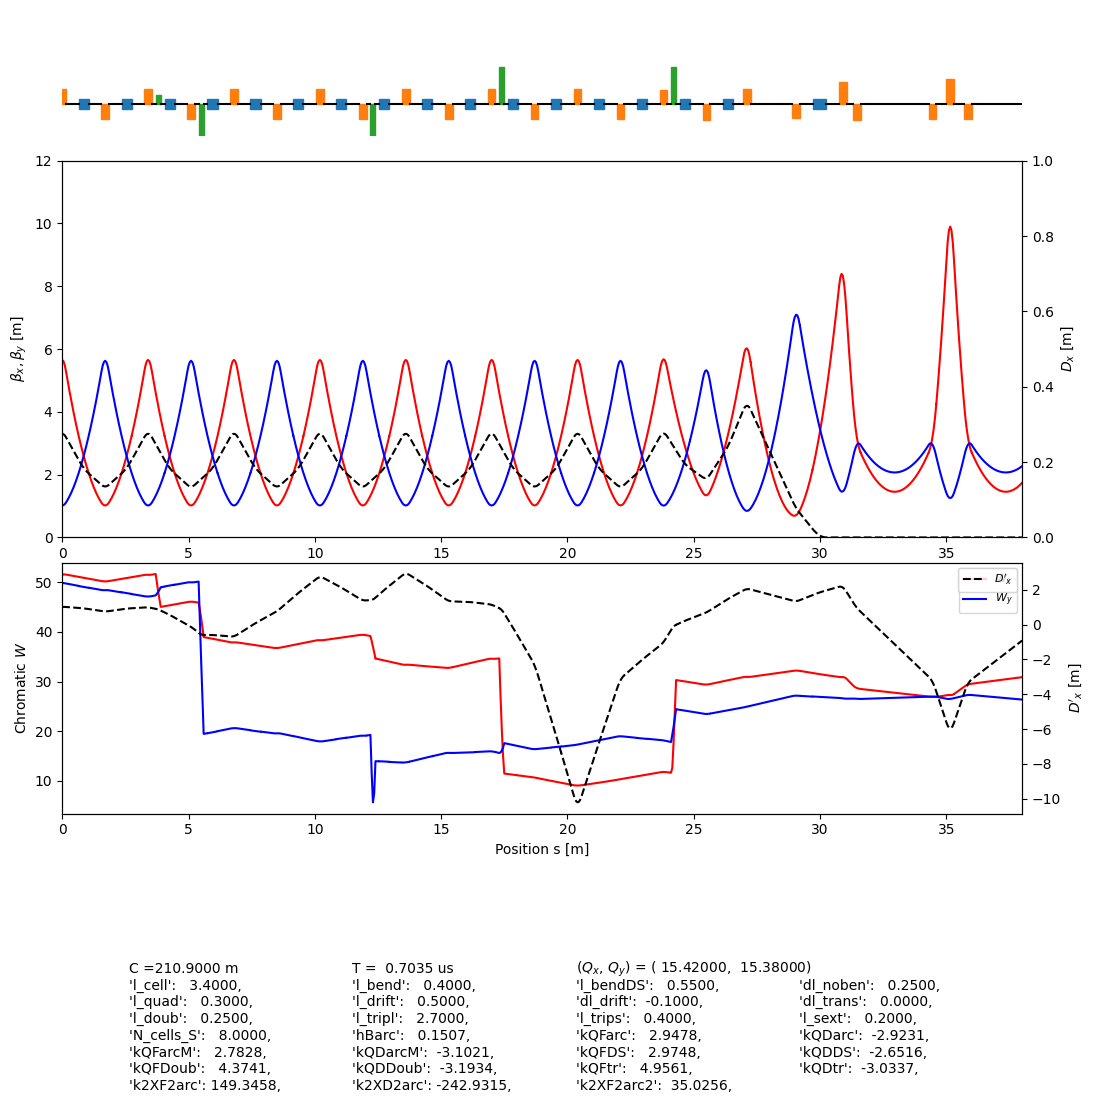

In [7]:


mf.SpuckParsAus( period_sliced.twiss(method='4d'), period,(0., 38.), (0., 12.), (0., 1.), .08,pdr, f"config_D{n}/Standard{n}.png" )

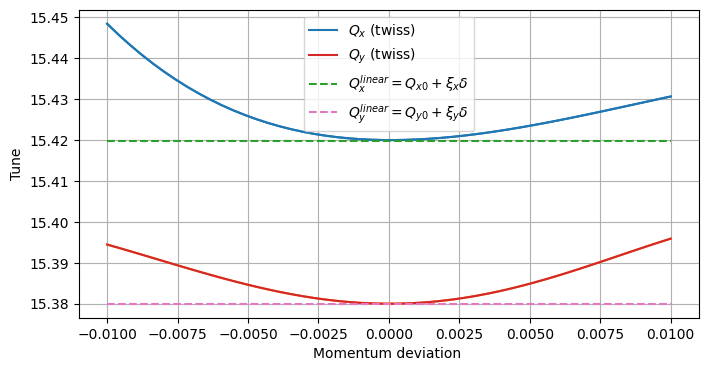

In [8]:
deltas = np.linspace(-1e-2,1e-2,50)

qx=[]
qy=[]
qx_shift=[]
qy_shift=[]
for d in deltas:
    ring.configure_radiation(model=None)
    tw=ring.twiss4d(delta0=d)
    qx.append(tw.qx)
    qy.append(tw.qy)

    qx_s=ring_tw.qx+ring_tw.dqx*d
    qx_shift.append(qx_s)
    qy_s=ring_tw.qy+ring_tw.dqy*d
    qy_shift.append(qy_s)



plt.figure(figsize=(8,4))
plt.plot(deltas,qx)
plt.plot(deltas, qy)    
plt.plot(deltas, qx, label='$Q_x$ (twiss)', color='tab:blue')
plt.plot(deltas, qy, label='$Q_y$ (twiss)', color='tab:red')

# Dotted/Dashed lines for the linear model
plt.plot(deltas, qx_shift, '--', label=f'$Q_x^{{linear}} = Q_{{x0}} + \\xi_x \\delta$', color='tab:green')
plt.plot(deltas, qy_shift, '--', label=f'$Q_y^{{linear}} = Q_{{y0}} + \\xi_y \\delta$', color='tab:pink')
plt.xlabel('Momentum deviation ')
plt.ylabel('Tune')
plt.legend()
plt.grid(True)
plt.savefig(f'config_D{n}/momentum_deviation{constants.WP}.png')

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/mwatson/ipykernel_549807/146360091.py:10: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(nominal_tw.qx,nominal_tw.qy, 'ro', label='Nominal ($\delta=0$)')


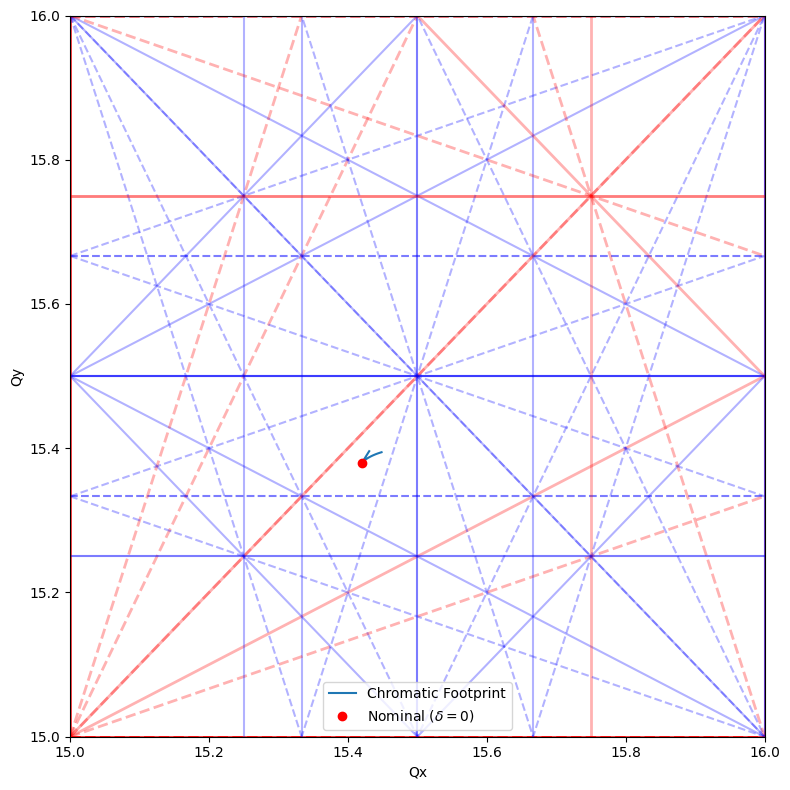

In [9]:

nominal_tw = ring.twiss4d(delta0=0)
'''Qx_range = (nominal_tw.qx-0.005,tw.qx+0.005)
Qy_range = (nominal_tw.qy-0.1,tw.qy+0.1)'''
resonances = resonance_lines(Qx_range,Qy_range,resonance_orders,3)
fig, ax = plt.subplots(1, figsize=(8,8), alpha=0.3)

ax.plot(qx, qy, label='Chromatic Footprint', color='tab:blue')

# Plot the actual center (delta=0)
ax.plot(nominal_tw.qx,nominal_tw.qy, 'ro', label='Nominal ($\delta=0$)')
ax.legend()
resonances.plot_resonance(fig)
plt.tight_layout()
plt.savefig(f'config_D{n}/momentum_dev_working_point_{n}.png')

In [10]:


line=ring
line.config.XTRACK_USE_EXACT_DRIFTS = True
xutil.set_integrator (line)
particle = 'positron'
operation_mode = 'z'
modes = {'z': 45.6e9, # in eV 
        'w': 80e9, # in eV
        'h': 120e9, # in eV 
        't': 182.5e9 # in eV
        }
energy = modes[operation_mode]


parameters = xutil.log_parameters (None, operation_mode, particle_type=particle, modes=modes)


# ## Choose a context
context = xo.ContextCpu()         # For CPU
context_tracking = xo.ContextCpu(omp_num_threads='auto') # For CPU with activate multi-core CPU parallelization


# ## Transfer lattice on context and compile tracking code
# line.build_tracker(_context=context)

# line.configure_radiation(model='mean')
# line.compensate_radiation_energy_loss()

tw = line.twiss(eneloss_and_damping=True)

#xutil.update_reference_parameters_from_line (line, parameters, BS_scale_factor=0, update_type='all', max_bb_param=0)
# xutil.correct_parameters_conflicts(parameters, update_study_parameters_from_reference=False)

gamma0 = ring.particle_ref.gamma0[0]
beta0 = ring.particle_ref.beta0[0]

n_emittancex = 1.8e-6 * gamma0 * beta0

parameters['study_parameters'] = {
    'ini_cond_type' : 'grid_DA', # grid_DA, grid_MA, distribution_matched, distribution_injected
    'output_dir' : 'out',
    'number_of_turns' : 2500,
    'number_of_particles' : 10000, 
    'inv1': 0, # np.arange(2)+1,
    'inv2': 0, # np.arange(2,2+3)+1,
    'start_element' : 'QD1_R1', # 'ca1.1','ip' #'rf400'
    'ini_cond_nemittance_x':13000e-6,
    'ini_cond_nemittance_y': 12000e-6,
    'ini_cond_bunch_length': 4.8e-3,
    'ini_cond_energy_spread': 2e-3,
    'ini_cond_energy_offset': None,
    'new_closed_orbit': None, # {'x': -x_co_inj_marker, 'px': None, 'y': None, 'py': None, 'zeta': None, 'delta': None}
    'covariance_dispertion_free': False
}


## Initial conditions
#particles = xutil.generate_particle_distribution (line, parameters['study_parameters'], beambeam_strength_used=1, radiation_off=True)
particles, grid_details = xutil.generate_particle_grid (line, parameters['study_parameters'])

## Tracking studies
line.configure_radiation(model='quantum')


## Change context for multy CPU for tracking
line.discard_tracker()
line.build_tracker(_context=context_tracking)


# Use tracking
line.track(particles, num_turns=parameters['study_parameters']['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) #, freeze_longitudinal=True
particles.sort(interleave_lost_particles=True)


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


/home/mwatson/.local/lib/python3.12/site-packages/xtrack/twiss.py:2107: RuntimeWarning: divide by zero encountered in divide
  damping_constants_turns * 2


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking: 100%|██████████| 2500/2500 [00:17<00:00, 145.22it/s]


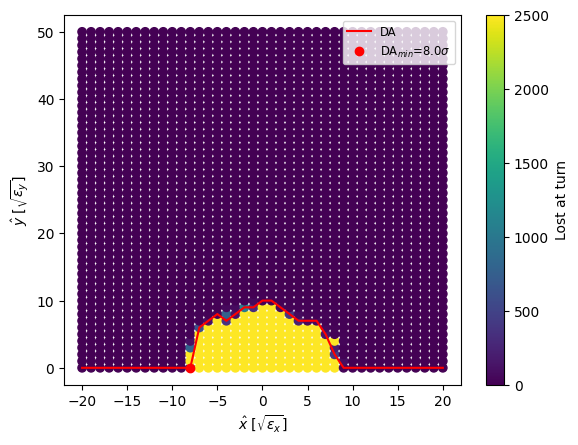

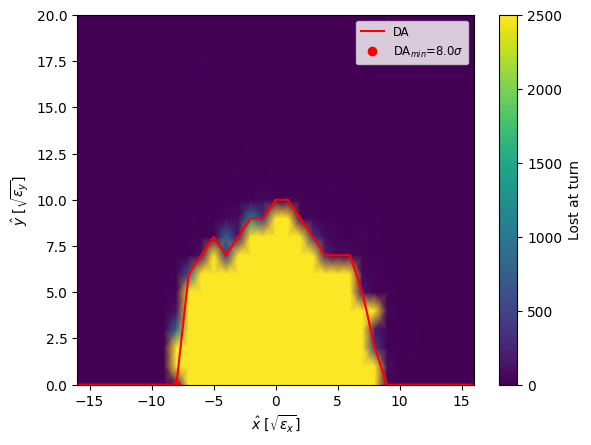

In [11]:
# dic_particles_all = xutil.tracking_data_process (tracking_data=line.record_last_track, 
#                             monitor_twiss=ring_tw.rows[0], 
#                             norm_emit_x=parameters['reference_parameters']['normalized_emittance_x'],
#                             norm_emit_y=parameters['reference_parameters']['normalized_emittance_y'],
#                             sigma_z=parameters['reference_parameters']['bunch_length'], 
#                             sigma_delta=parameters['reference_parameters']['energy_spread'],
#                             particle_id_to_use='all')
# xutil.save_dict_to_h5(f'{output_dir}/dic_particles_all.h5', dic_particles_all)



# liftime = my_xpf.particle_population_vs_turns (dic_particles_all['state'], T_rev0=tw.T_rev0)
# my_xpf.phase_space_evolution_difference (dic_particles_all['zeta'][:,0], dic_particles_all['delta'][:,0], dic_particles_all['zeta'][:,-1], dic_particles_all['delta'][:,-1], x_axis_label=r'$z~[m]$', y_axis_label=r'$\delta$')
# my_xpf.phase_space_evolution_difference (dic_particles_all['x'][:,0], dic_particles_all['px'][:,0], dic_particles_all['x'][:,-1], dic_particles_all['px'][:,-1], x_axis_label=r'$x~[m]$', y_axis_label=r'$px$')
# my_xpf.emittances_vs_turns (dic_particles_all['emit_x'], dic_particles_all['emit_y'], dic_particles_all['emit_zeta'], reference_emit_x=ref_param['emittance_x'], reference_emit_y=ref_param['emittance_y'], reference_emit_z=ref_param['energy_spread']*ref_param['bunch_length'], log_y_axis=True)
# my_xpf.coordinates_vs_turns (dic_particles_all['x_sigma'], dic_particles_all['px_sigma'], dic_particles_all['at_turn'], r'$x~[\sigma_x]$', r'$p_x~[\sigma_x]$', particle_id_list=dic_particles_all['particle_id_list'], full_init_cond=study_param['number_of_particles'])
# my_xpf.MA_vs_turns(particles, grid_details['num_r_y_points'], grid_details['num_delta'], grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'])
my_xpf.DA_vs_turns(particles, grid_details['num_r_y_points'], grid_details['num_theta_x_points'], grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'])
plt.xlim(-16,16)
plt.ylim(0,20)
plt.savefig(f"config_D{n}/DA_plot_{n}_WP{constants.WP}.png")

/home/mwatson/Documents/laughing-octo-bassoon/xutil_DA_CC/xsuite_utilities.py:4333: RuntimeWarning: divide by zero encountered in divide
  delta_s_dist_evol = delta_cor/np.sqrt(sigma_matrix[5,5,:])


0 / 2091
1 / 2091
2 / 2091
3 / 2091
4 / 2091
5 / 2091
6 / 2091
7 / 2091
8 / 2091
9 / 2091
10 / 2091
11 / 2091
12 / 2091
13 / 2091
14 / 2091
15 / 2091
16 / 2091
17 / 2091
18 / 2091
19 / 2091
20 / 2091
21 / 2091
22 / 2091
23 / 2091
24 / 2091
25 / 2091
26 / 2091
27 / 2091
28 / 2091
29 / 2091
30 / 2091
31 / 2091
32 / 2091
33 / 2091
34 / 2091
35 / 2091
36 / 2091
37 / 2091
38 / 2091
39 / 2091
40 / 2091
41 / 2091
42 / 2091
43 / 2091
44 / 2091
45 / 2091
46 / 2091
47 / 2091
48 / 2091
49 / 2091
50 / 2091
51 / 2091
52 / 2091
53 / 2091
54 / 2091
55 / 2091
56 / 2091
57 / 2091
58 / 2091
59 / 2091
60 / 2091
61 / 2091
62 / 2091
63 / 2091
64 / 2091
65 / 2091
66 / 2091
67 / 2091
68 / 2091
69 / 2091
70 / 2091
71 / 2091
72 / 2091
73 / 2091
74 / 2091
75 / 2091
76 / 2091
77 / 2091
78 / 2091
79 / 2091
80 / 2091
81 / 2091
82 / 2091
83 / 2091
84 / 2091
85 / 2091
86 / 2091
87 / 2091
88 / 2091
89 / 2091
90 / 2091
91 / 2091
92 / 2091
93 / 2091
94 / 2091
95 / 2091
96 / 2091
97 / 2091
98 / 2091
99 / 2091
100 / 2091

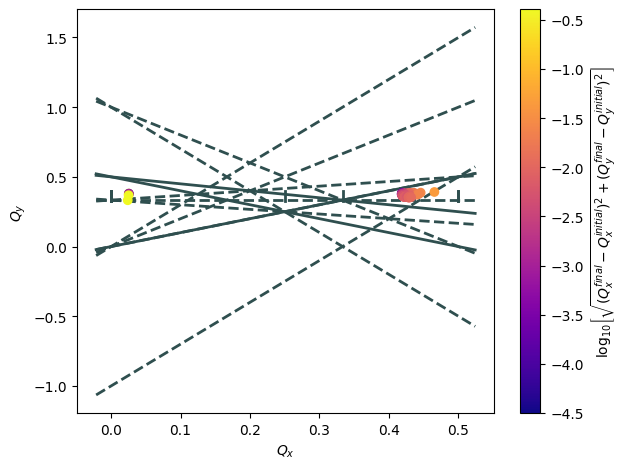

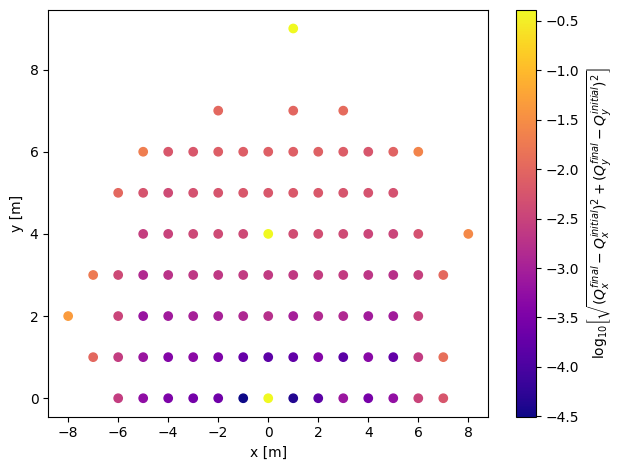

In [12]:

tracking_data=xutil.tracking_data_process (tracking_data=line.record_last_track, 
                            #monitor_twiss=tw.rows[0], 
                            norm_emit_x=parameters['reference_parameters']['normalized_emittance_x'],
                            norm_emit_y=parameters['reference_parameters']['normalized_emittance_y'],
                            sigma_z=parameters['reference_parameters']['bunch_length'], 
                            sigma_delta=parameters['reference_parameters']['energy_spread'],
                            particle_id_to_use='all')

Qx_start = xutil.nafflib_tune_calculation(tracking_data['x'][:, :1000], pq_coordinates=tracking_data['px'][:, :1000], number_harmonics=1)
Qy_start = xutil.nafflib_tune_calculation(tracking_data['y'][:, :1000], pq_coordinates=tracking_data['py'][:, :1000], number_harmonics=1)

# Window 2: Last 1000 turns (e.g., from turn 1000 to 2000)
Qx_end = xutil.nafflib_tune_calculation(tracking_data['x'][:, 1500:2500], pq_coordinates=tracking_data['px'][:, 1500:2500], number_harmonics=1)
Qy_end = xutil.nafflib_tune_calculation(tracking_data['y'][:, 1500:2500], pq_coordinates=tracking_data['py'][:, 1500:2500], number_harmonics=1)



my_xpf.tune_diffusion (Qx_start['Q1'], Qx_end['Q1'], Qy_start['Q1'], Qy_end['Q1'], initial_conditions_x_axis=grid_details['x_normalized'], initial_conditions_y_axis=grid_details['y_normalized'], xlabel='x [m]', ylabel='y [m]', resonance_orders=(1,2,3,4), annotate=False, delta_value= None)

In [13]:
line.configure_radiation(model=None)

parameters['study_parameters'] = {
    'ini_cond_type' : 'grid_MA', # grid_DA, grid_MA, distribution_matched, distribution_injected
    'output_dir' : 'out',
    'number_of_turns' : 2500,
    'number_of_particles' : 1000, 
    'inv1': 0, # np.arange(2)+1,
    'inv2': 0, # np.arange(2,2+3)+1,
    'start_element' : 'QD1_R1', # 'ca1.1','ip' #'rf400'
    'ini_cond_nemittance_x':13000e-6,
    'ini_cond_nemittance_y': 12000e-6,
    'ini_cond_bunch_length': 4.8e-3,
    'ini_cond_energy_spread': 2e-3,
    'ini_cond_energy_offset': None,
    'new_closed_orbit': None, # {'x': -x_co_inj_marker, 'px': None, 'y': None, 'py': None, 'zeta': None, 'delta': None}
    'covariance_dispertion_free': False
}


## Initial conditions
#particles = xutil.generate_particle_distribution (line, parameters['study_parameters'], beambeam_strength_used=1, radiation_off=True)
particles, grid_details = xutil.generate_particle_grid (line, parameters['study_parameters'])
print(grid_details)

## Tracking studies
line.configure_radiation(model='quantum')


## Change context for multy CPU for tracking
line.discard_tracker()
line.build_tracker(_context=context_tracking)


# Use tracking
line.track(particles, num_turns=parameters['study_parameters']['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) #, freeze_longitudinal=True
particles.sort(interleave_lost_particles=True)


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...


/home/mwatson/.local/lib/python3.12/site-packages/xtrack/twiss.py:2107: RuntimeWarning: divide by zero encountered in divide
  damping_constants_turns * 2


Done compiling ContextCpu kernels.
{'num_theta_x_points': 1, 'num_r_y_points': 31, 'num_delta': 51, 'num_particles': 1581, 'x_normalized': array([ 0.        ,  0.70710678,  1.41421356, ..., 19.79898987,
       20.50609665, 21.21320344]), 'y_normalized': array([ 0.        ,  0.70710678,  1.41421356, ..., 19.79898987,
       20.50609665, 21.21320344]), 'delta_init': array([-0.05, -0.05, -0.05, ...,  0.05,  0.05,  0.05])}
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking: 100%|██████████| 2500/2500 [00:19<00:00, 129.48it/s]


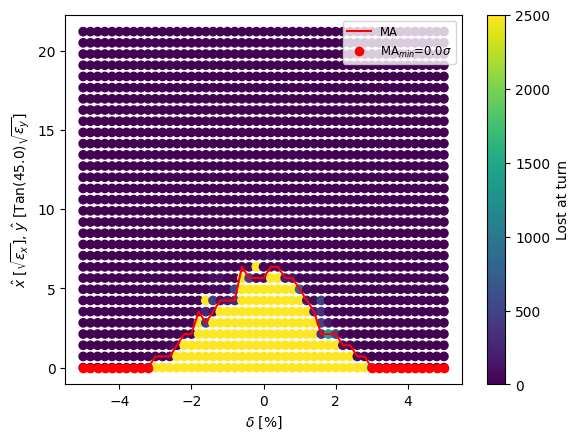

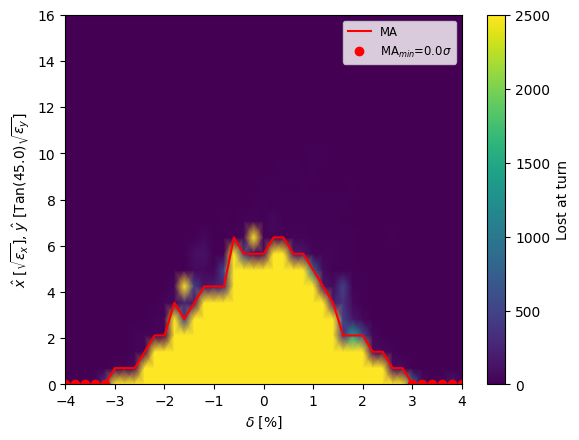

In [14]:
my_xpf.MA_vs_turns(particles, grid_details['num_r_y_points'], 51, grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'])
plt.xlim(-4,4)
plt.ylim(0,16)
plt.savefig(f"config_D{n}/MA_plot_{n}_WP{constants.WP}.png")

In [15]:
pdf.close()

In [16]:
context = xo.ContextCpu(omp_num_threads=None)

# %% Simple test of tracking with synchrotron radiation - takes some time
ring.configure_radiation(model='mean')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True)
#ring_tw.plot()
#print( ring_tw.keys() )
print( f' Energy loss per turn from twiss {ring_tw.eneloss_turn:10.2f} and me {U0:10.2f}')
print( 1/ring_tw.damping_constants_turns )
print( 2*E0/ring_tw.eneloss_turn )

npts = 200
epsx, epsy, epsl = 1.0e-7, 1.0e-7, 1.0e-4  # starting with somewhat large emittances
betxin, alfxin  = ring_tw.betx[0], ring_tw.alfx[0] 
xin, pxin       = ring_tw.x[0], ring_tw.px[0]
dxin, dpxin     = ring_tw.dx[0], ring_tw.dpx[0]
betyin, alfyin  = ring_tw.bety[0], ring_tw.alfy[0] 
yin, pyin       = ring_tw.y[0], ring_tw.py[0]   # should be zero for perfect case
#epsx, epsl      = 2.0*ring_tw.eq_gemitt_x, 2.0*ring_tw.eq_gemitt_zeta
betlin          = ring_tw.bets0
zetain, deltain = ring_tw.zeta[0], ring_tw.delta[0]
print( f'At reference location: D ={dxin:7.4f} m, Dp ={dpxin:7.4f},' +
       f' betx ={betxin:7.4f} m, alfx ={alfxin:7.4f},' + 
       f' betl ={betlin:7.4f} m ')

normat = np.array([
    [(epsx*betxin)**.5,         0,                 0,  0, 0, dxin*(epsl/betlin)**.5],
    [-alfxin*(epsx/betxin)**.5, (epsx/betxin)**.5, 0,  0, 0, dpxin*(epsl/betlin)**.5],
    [0,  0,  (epsx*betyin)**.5,         0,                 0, 0],
    [0,  0,  -alfyin*(epsx/betyin)**.5, (epsx/betyin)**.5, 0, 0],
    [0, 0, 0, 0, (epsl*betlin)**.5, 0                ],
    [0, 0, 0, 0, 0,                 (epsl/betlin)**.5]               
    ])

parts = np.array([
     [xin, pxin, yin, pyin, zetain, deltain] + normat@np.random.randn(6) 
         for ind in range(npts) ]).T
# quit()
p2 = xt.Particles(kinetic_energy0 = 2860.e6, mass0 = xt.ELECTRON_MASS_EV,
                  x    = parts[0], px   = parts[1],
                  y    = parts[2], py   = parts[3],
                  zeta = parts[4], delta = parts[5] )
ring.configure_radiation(model='quantum')
ring.track( p2, num_turns = 6100, turn_by_turn_monitor = True,
            with_progress = True )

data = ring.record_last_track
trnplt = [1, 2000, 4000, 6000]
#trnplt = range( len(data.x.T) ) # superimpose all turns, rendering is slowish
fig = plt.figure( figsize=(14., 4.) )
fig.suptitle( f'Phase Space Plots - particle survival {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
ax = fig.subplots(1, 3)
fig.subplots_adjust( wspace=0.4 )
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel("x' (mrad)")
ax[1].set_xlabel('y (mm)')
ax[1].set_ylabel("y' (mrad)")
ax[2].set_xlabel('z (mm)')
ax[2].set_ylabel(r'rel. mom. offset ($10^{-3}$)')
for ind in range( len(trnplt) ):  # data.x.T[ind] is nparray (behaviour of multiplication)!
   print( f' ==> Plotting turn"{trnplt[ind]:5d}')
   ax[0].scatter( 1000*(data.x.T[trnplt[ind]] - 1.*ring_tw.dx[0]*data.delta.T[trnplt[ind]]), 
            1000*(data.px.T[trnplt[ind]] - 1.*ring_tw.dpx[0]*data.delta.T[trnplt[ind]]),
            s=.4, c = f'C{ind:1d}')
   ax[1].scatter( 1000*(data.y.T[trnplt[ind]]), 1000*(data.py.T[trnplt[ind]]), 
            s=.2, c = f'C{ind:1d}' )
   ax[2].scatter(1000*data.zeta.T[trnplt[ind]], 1000*data.delta.T[trnplt[ind]], 
            s=.2, color=f'C{ind:1d}' )

print( [pdr['RFCav_1'].lag, pdr['RFCav_1'].voltage] )

print( f' Particle survival: {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
plt.savefig(f'config_D{n}/Particle_survival_{n}.png')

AssertionError: Twiss with radiation computation is not supported with OpenMP parallelization